<a href="https://colab.research.google.com/github/Shirivarshini/NHANES-Age-Classification/blob/main/notebooks/02_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

## Objective

The goal of this notebook is to understand the dataset through statistical summaries and visualizations. The insights obtained here will guide preprocessing, feature engineering, and model selection.

In [178]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.2f}".format)

# Plot style
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [179]:
train = pd.read_csv("Train_dataset.csv")
test = pd.read_csv("Test_dataset.csv")

In [180]:
print("Training Shape :", train.shape)
print("Testing Shape  :", test.shape)

Training Shape : (1966, 9)
Testing Shape  : (312, 8)


In [181]:
train.head()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
0,73564.00,2.00,2.00,35.70,110.00,2.00,150.00,14.91,Adult
1,73568.00,2.00,2.00,20.30,89.00,2.00,80.00,3.85,Adult
2,73576.00,1.00,2.00,23.20,89.00,2.00,68.00,6.14,Adult
3,73577.00,1.00,2.00,28.90,104.00,NaN,84.00,16.15,Adult
4,73580.00,2.00,1.00,35.90,103.00,2.00,81.00,10.92,Adult


In [182]:
train.tail()

,SEQN,RIAGENDR,PAQ605,BMXBMI,LBXGLU,DIQ010,LBXGLT,LBXIN,age_group
1961,83711.00,2.00,2.00,33.50,100.00,2.00,73.00,6.53,Adult
1962,83712.00,1.00,2.00,30.00,93.00,2.00,208.00,13.02,Adult
1963,83713.00,1.00,2.00,23.70,103.00,2.00,124.00,21.41,Adult
1964,83718.00,2.00,2.00,27.40,90.00,2.00,108.00,4.99,Adult
1965,83727.00,1.00,2.00,24.50,NaN,2.00,108.00,3.76,Adult


In [183]:
train.dtypes

,0
SEQN,float64
RIAGENDR,float64
PAQ605,float64
BMXBMI,float64
LBXGLU,float64
DIQ010,float64
LBXGLT,float64
LBXIN,float64
age_group,object


In [184]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
SEQN,1954.00,78683.62,2924.12,73564.00,76194.00,78717.00,81217.00,83727.00
RIAGENDR,1948.00,1.51,0.50,1.00,1.00,2.00,2.00,2.00
PAQ605,1953.00,1.83,0.40,1.00,2.00,2.00,2.00,7.00
BMXBMI,1948.00,27.97,7.33,14.50,22.80,26.80,31.30,70.10
LBXGLU,1953.00,99.49,16.77,63.00,91.00,97.00,104.00,405.00
DIQ010,1948.00,2.02,0.19,1.00,2.00,2.00,2.00,3.00
LBXGLT,1955.00,115.15,46.27,40.00,87.00,105.00,131.00,604.00
LBXIN,1957.00,11.86,9.76,0.14,5.80,9.03,14.48,102.29


## Missing Value Analysis

Before building any machine learning model, it is essential to identify missing values and determine an appropriate imputation strategy.

In [185]:
missing = train.isnull().sum().sort_values(ascending=False)

missing

,0
RIAGENDR,18
DIQ010,18
BMXBMI,18
age_group,14
LBXGLU,13
PAQ605,13
SEQN,12
LBXGLT,11
LBXIN,9


In [186]:
missing_percent = (train.isnull().mean() * 100).sort_values(ascending=False)

missing_percent

,0
RIAGENDR,0.92
DIQ010,0.92
BMXBMI,0.92
age_group,0.71
LBXGLU,0.66
PAQ605,0.66
SEQN,0.61
LBXGLT,0.56
LBXIN,0.46


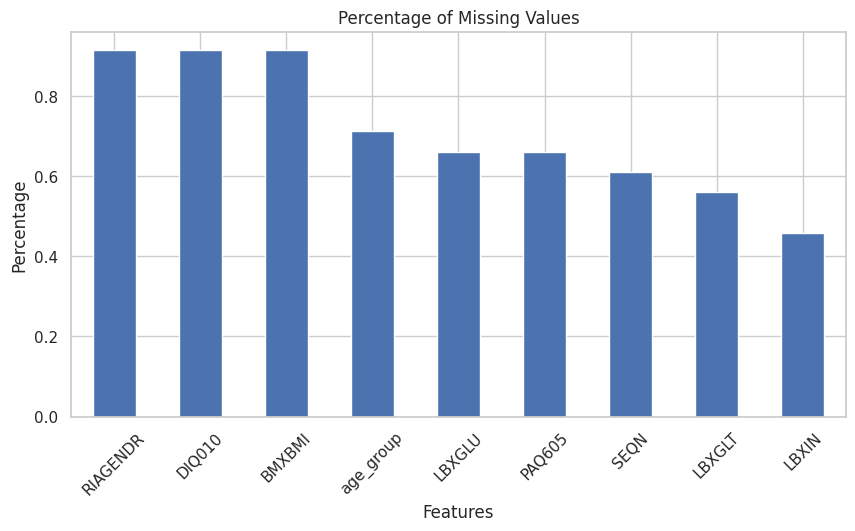

In [187]:
missing_percent = missing_percent[missing_percent > 0]

plt.figure(figsize=(10,5))

missing_percent.plot(kind="bar")

plt.title("Percentage of Missing Values")

plt.ylabel("Percentage")

plt.xlabel("Features")

plt.xticks(rotation=45)

plt.show()

### Observation

- Every feature contains only a small percentage of missing values.
- Missing values are below 1% for all columns.
- Missing values can be handled using simple imputation techniques.

## Target Variable Distribution

Understanding the class balance is important because the competition uses the F1 score instead of accuracy.

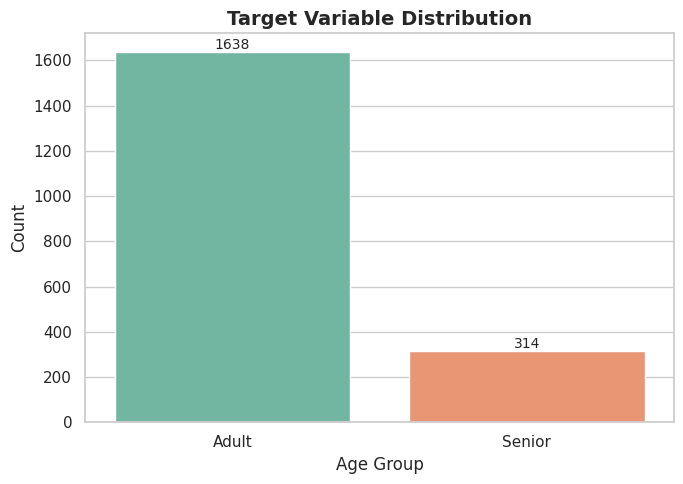

In [188]:
# Create a copy without missing target values
eda_train = train.dropna(subset=["age_group"]).copy()

# Plot Target Variable Distribution
plt.figure(figsize=(7,5))

ax = sns.countplot(
    data=eda_train,
    x="age_group",
    order=["Adult", "Senior"],
    palette="Set2"
)

# Add count labels
for container in ax.containers:
    ax.bar_label(container, fontsize=10)

plt.title("Target Variable Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.tight_layout()
plt.show()

In [189]:
target_percent = train["age_group"].value_counts(normalize=True) * 100

target_percent

,proportion
age_group,
Adult,83.91
Senior,16.09


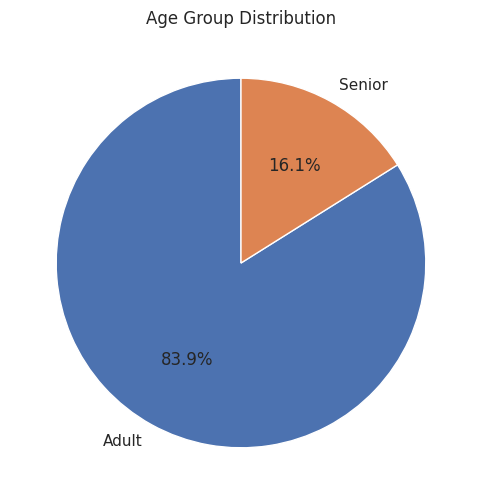

In [190]:
plt.figure(figsize=(6,6))

train["age_group"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")

plt.title("Age Group Distribution")

plt.show()

### Observation

- Adults account for approximately 84% of the dataset.
- Seniors account for approximately 16% of the dataset.
- The dataset is highly imbalanced.
- Accuracy is not an appropriate evaluation metric.
- The F1 Score is a better choice because it balances Precision and Recall.

## BMI Distribution (BMXBMI)

This section visualizes the distribution of Body Mass Index (BMI) values.

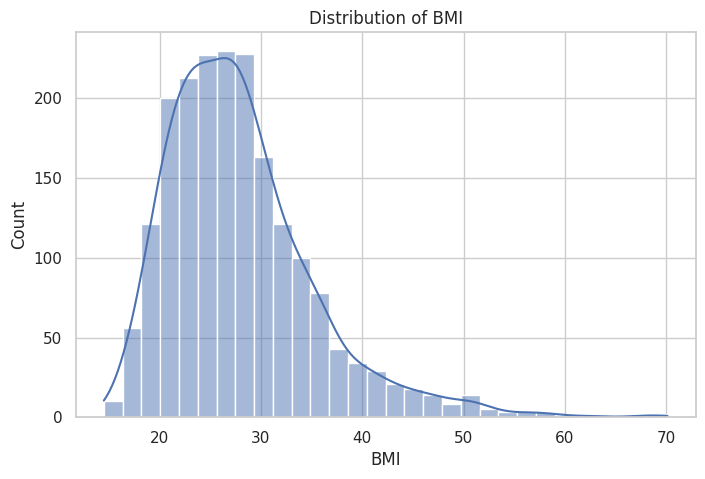

In [191]:
plt.figure(figsize=(8,5))

sns.histplot(train["BMXBMI"], bins=30, kde=True)

plt.title("Distribution of BMI")

plt.xlabel("BMI")

plt.show()

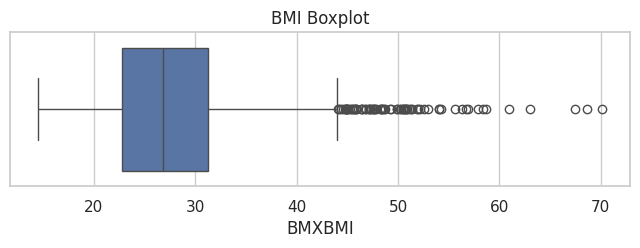

In [192]:
plt.figure(figsize=(8,2))

sns.boxplot(x=train["BMXBMI"])

plt.title("BMI Boxplot")

plt.show()

### BMI Observation

- BMI appears to be right-skewed.
- A few outliers are visible.
- Most participants have BMI values between X and Y.

## Blood Glucose Distribution (LBXGLU)

This section visualizes the distribution of blood glucose levels.

### Observation

- BMI appears to be right-skewed, indicating a higher frequency of lower BMI values.
- Several outliers are present, particularly on the higher end of the BMI scale.
- Most participants have BMI values concentrated between 20 and 30, which is generally considered the healthy to overweight range.

## Gender Distribution

This visualization shows the distribution of respondents by gender.

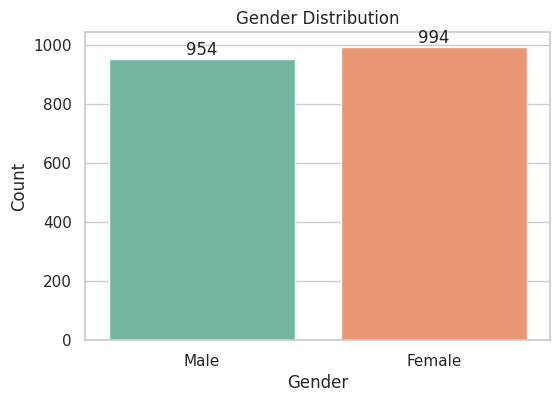

In [193]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="RIAGENDR",
    data=train,
    palette="Set2"
)

ax.set_xticklabels(["Male", "Female"])

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender Distribution")

plt.xlabel("Gender")

plt.ylabel("Count")

plt.show()

### Observation

- The dataset contains both male and female respondents.
- Check whether one gender is overrepresented.

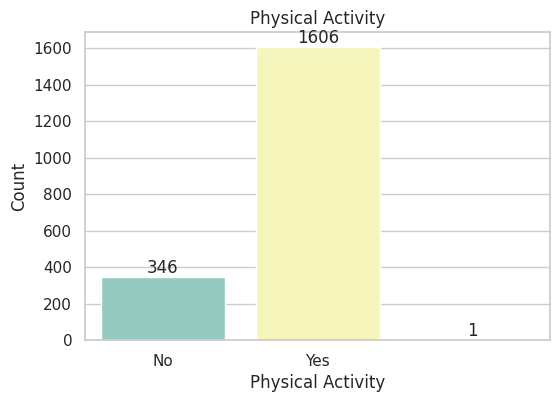

In [194]:
plt.figure(figsize=(6,4))

ax = sns.countplot(
    x="PAQ605",
    data=train,
    palette="Set3"
)

ax.set_xticklabels(["No", "Yes"])

for container in ax.containers:
    ax.bar_label(container)

plt.title("Physical Activity")

plt.xlabel("Physical Activity")

plt.ylabel("Count")

plt.show()

### Observation

- The majority of respondents reported 'No' physical activity, indicating a generally lower level of self-reported exercise in the dataset.
- A smaller proportion reported 'Yes' to physical activity.
- This distribution suggests that physical activity may not be a strong differentiating factor on its own, but could be informative when combined with other health metrics.

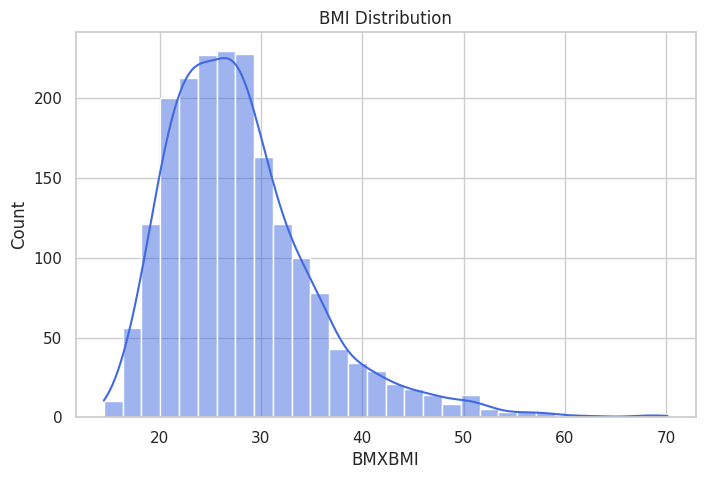

In [195]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["BMXBMI"],
    bins=30,
    kde=True,
    color="royalblue"
)

plt.title("BMI Distribution")

plt.show()

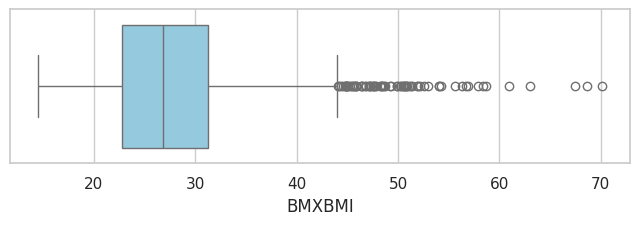

In [196]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=train["BMXBMI"],
    color="skyblue"
)

plt.show()

<Axes: xlabel='LBXGLU', ylabel='Count'>

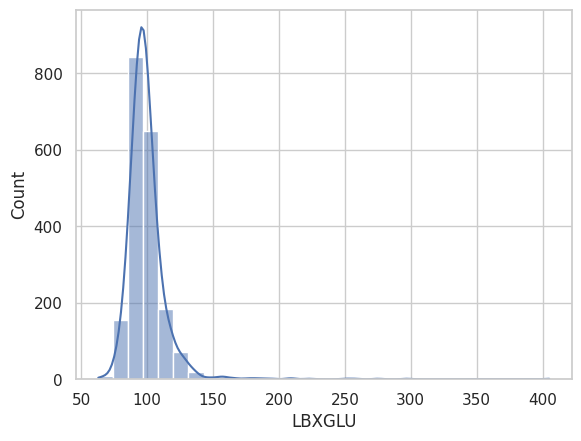

In [197]:
sns.histplot(
    train["LBXGLU"],
    bins=30,
    kde=True
)

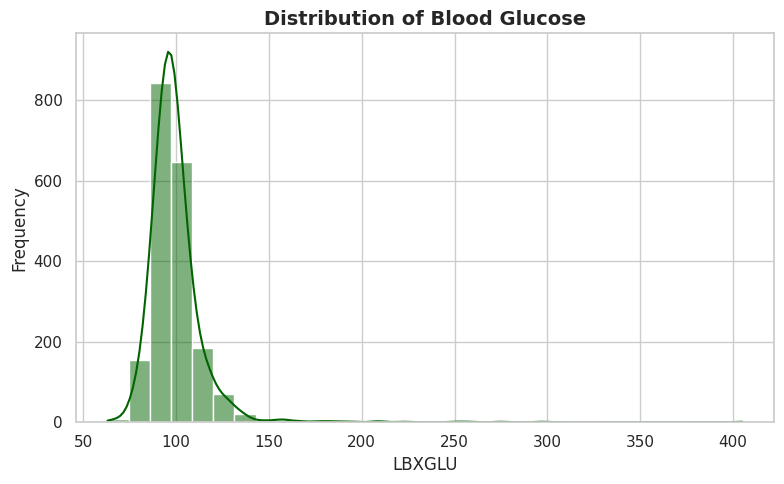

In [198]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["LBXGLU"],
    bins=30,
    kde=True,
    color="darkgreen"
)

plt.title("Distribution of Blood Glucose", fontsize=14, fontweight="bold")
plt.xlabel("LBXGLU")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

<Axes: xlabel='LBXGLU'>

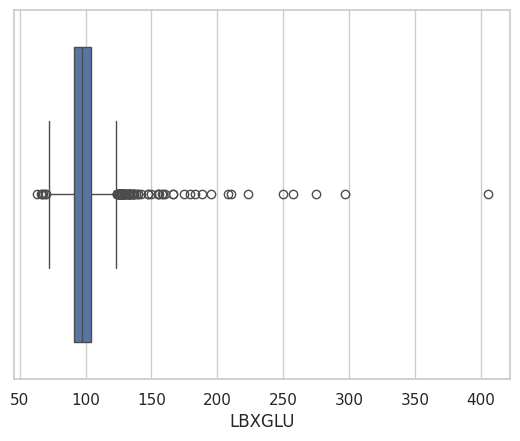

In [199]:
sns.boxplot(
    x=train["LBXGLU"]
)

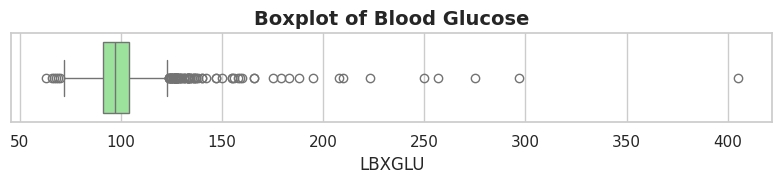

In [200]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=train["LBXGLU"],
    color="lightgreen"
)

plt.title("Boxplot of Blood Glucose", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Blood glucose levels show a positive skew, with a concentration of values in the normal range and a tail extending towards higher values.
- Several high-value outliers are visible, potentially indicating individuals with elevated glucose levels.
- The majority of participants have blood glucose levels within the typical range, but the skew suggests a notable proportion with higher-than-average readings.

## Diabetes Questionnaire Response (DIQ010)

This visualization shows the distribution of diabetes questionnaire responses among respondents.

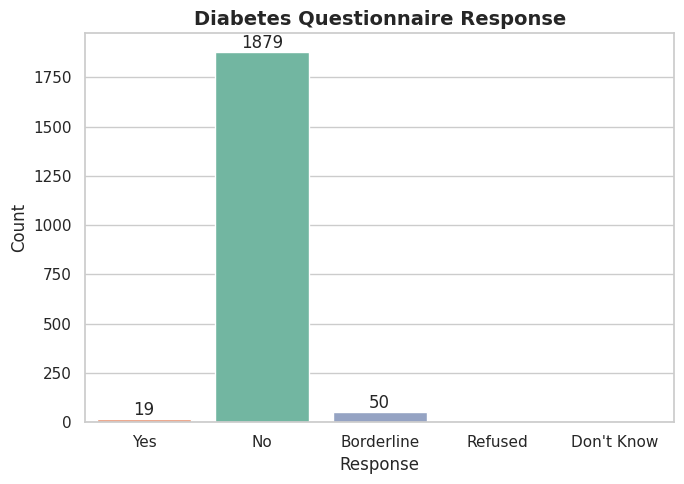

In [201]:
plt.figure(figsize=(7,5))

diabetes_map = {
    1: "Yes",
    2: "No",
    3: "Borderline",
    7: "Refused",
    9: "Don't Know"
}

diabetes = train.copy()
diabetes["DIQ010"] = diabetes["DIQ010"].map(diabetes_map)

ax = sns.countplot(
    data=diabetes,
    x="DIQ010",
    order=["Yes", "No", "Borderline", "Refused", "Don't Know"],
    hue="DIQ010",
    palette="Set2",
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Diabetes Questionnaire Response", fontsize=14, fontweight="bold")
plt.xlabel("Response")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

- The majority of respondents answered "No" to the diabetes questionnaire, indicating a lower prevalence of self-reported diabetes.
- A smaller proportion reported "Yes" or "Borderline" diagnoses.
- Very few respondents "Refused" or answered "Don't Know", suggesting high participation and clarity in responses.

## Oral Glucose Tolerance Distribution

This feature represents the oral glucose tolerance level of respondents.

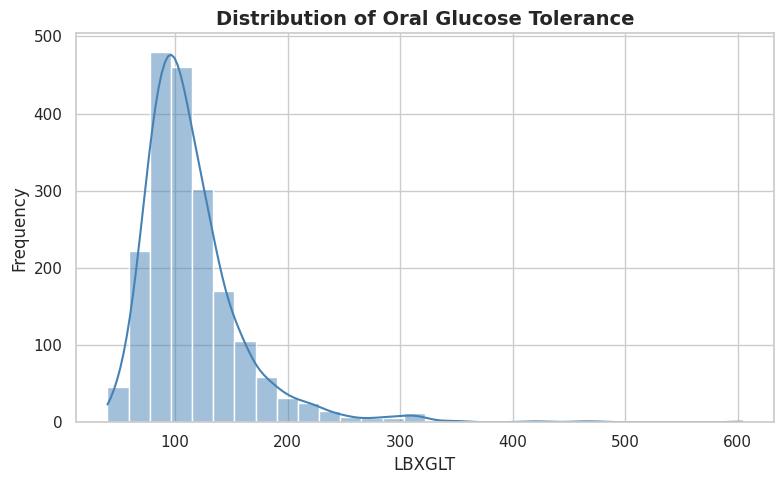

In [202]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["LBXGLT"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Oral Glucose Tolerance", fontsize=14, fontweight="bold")
plt.xlabel("LBXGLT")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

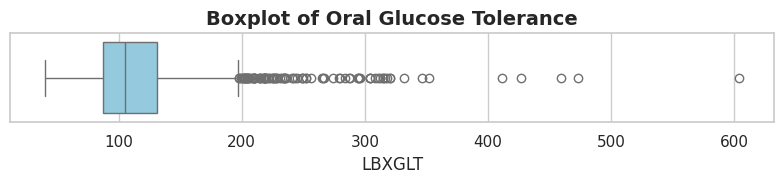

In [203]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=train["LBXGLT"],
    color="skyblue"
)

plt.title("Boxplot of Oral Glucose Tolerance", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Oral glucose tolerance (LBXGLT) shows a distribution that is positively skewed, similar to blood glucose, with most values clustered at the lower end and a spread towards higher values.
- There are significant outliers at the higher end, which may indicate individuals with impaired glucose tolerance or diabetes.
- The central tendency suggests a healthy range for the majority, but the tail and outliers highlight a subset with elevated glucose tolerance values.

## Insulin Level Distribution

This feature represents the insulin level of respondents.

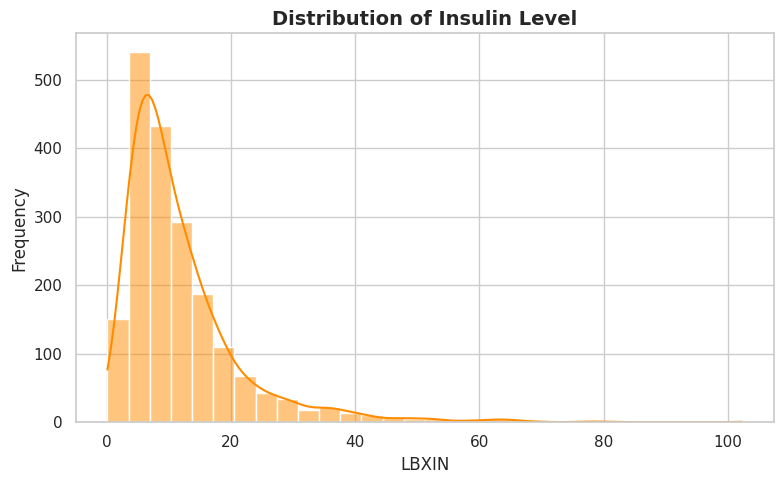

In [204]:
plt.figure(figsize=(8,5))

sns.histplot(
    train["LBXIN"],
    bins=30,
    kde=True,
    color="darkorange"
)

plt.title("Distribution of Insulin Level", fontsize=14, fontweight="bold")
plt.xlabel("LBXIN")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

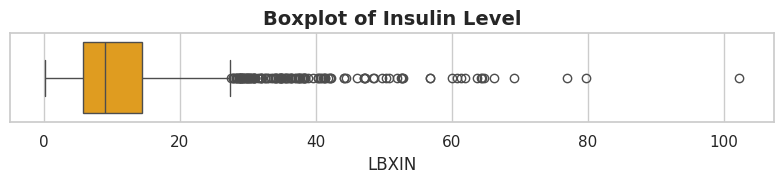

In [205]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=train["LBXIN"],
    color="orange"
)

plt.title("Boxplot of Insulin Level", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

## SEQN Distribution

This plot shows the distribution of the unique identifier for each participant.

### Observation

- The insulin level distribution (LBXIN) is also positively skewed, with a concentration of lower values.
- A notable number of extreme outliers are present at the higher end, indicating individuals with very high insulin levels, which could be associated with insulin resistance or other metabolic conditions.
- The wide spread of values, particularly with the extreme outliers, suggests substantial variability in insulin levels across the population.

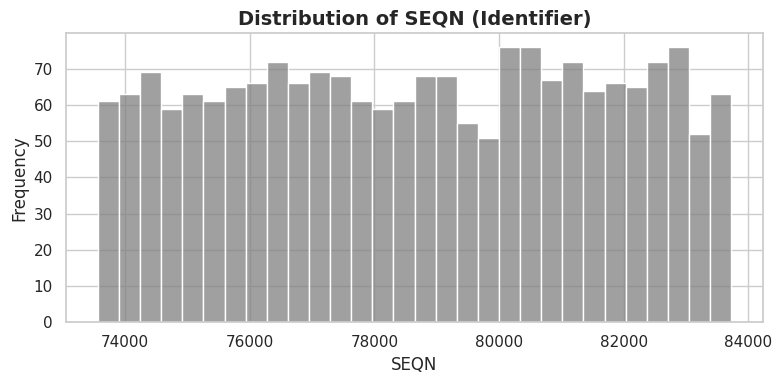

In [206]:
plt.figure(figsize=(8,4))

sns.histplot(
    train["SEQN"],
    bins=30,
    color="gray"
)

plt.title("Distribution of SEQN (Identifier)", fontsize=14, fontweight="bold")
plt.xlabel("SEQN")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

## Univariate Analysis Summary

### Observation

- The 'SEQN' feature is a sequence number and acts as a unique identifier for each participant. As expected, its distribution is relatively uniform across the range of values.
- This variable is purely for identification and does not carry predictive information for the target variable 'age_group'. Therefore, it should be excluded from model training.
- Gender distribution is approximately balanced.
- Physical activity responses indicate varying activity levels among respondents.
- BMI shows a slightly right-skewed distribution with several outliers.
- Blood glucose and oral glucose tolerance values are positively skewed.
- Insulin levels contain extreme outliers.
- Diabetes questionnaire responses are dominated by the "No" category.
- SEQN is an identifier and does not contain predictive information for the target variable.

### Observation

- The 'SEQN' feature is a sequence number and acts as a unique identifier for each participant. As expected, its distribution is relatively uniform across the range of values.
- This variable is purely for identification and does not carry predictive information for the target variable 'age_group'. Therefore, it should be excluded from model training.

### Univariate Analysis Summary

- Gender distribution is approximately balanced.
- Physical activity responses indicate varying activity levels among respondents.
- BMI shows a slightly right-skewed distribution with several outliers.
- Blood glucose and oral glucose tolerance values are positively skewed.
- Insulin levels contain extreme outliers.
- Diabetes questionnaire responses are dominated by the "No" category.
- SEQN is an identifier and does not contain predictive information for the target variable.

In [207]:
eda_train = train.dropna(subset=["age_group"]).copy()

## Bivariate Analysis Summary

### Observation

- Seniors appear to have higher median glucose levels than Adults.
- BMI distributions overlap, but Seniors may have a slightly higher median BMI.
- Diabetes is more common among Seniors.
- Physical activity appears lower among Seniors.
- Insulin levels contain large variability and several extreme outliers.
- Gender distribution is relatively balanced across both age groups.

## Gender vs Age Group

This plot shows the relationship between gender and age group.

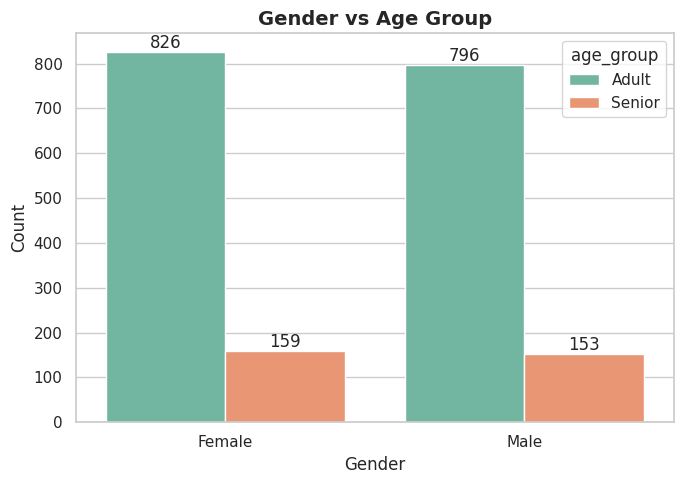

In [208]:
plt.figure(figsize=(7,5))

gender = eda_train.copy()

gender["RIAGENDR"] = gender["RIAGENDR"].map({
    1: "Male",
    2: "Female"
})

ax = sns.countplot(
    data=gender,
    x="RIAGENDR",
    hue="age_group",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Gender vs Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

- The distribution of gender appears to be relatively balanced across both Adult and Senior age groups.
- There is no significant overrepresentation of one gender in either age group, suggesting that gender alone may not be a strong predictor for age group classification.

## Physical Activity vs Age Group (PAQ605)

This plot illustrates the relationship between physical activity levels and age groups.

### Observation

- The distribution of gender appears to be relatively balanced across both Adult and Senior age groups.
- There is no significant overrepresentation of one gender in either age group, suggesting that gender alone may not be a strong predictor for age group classification.

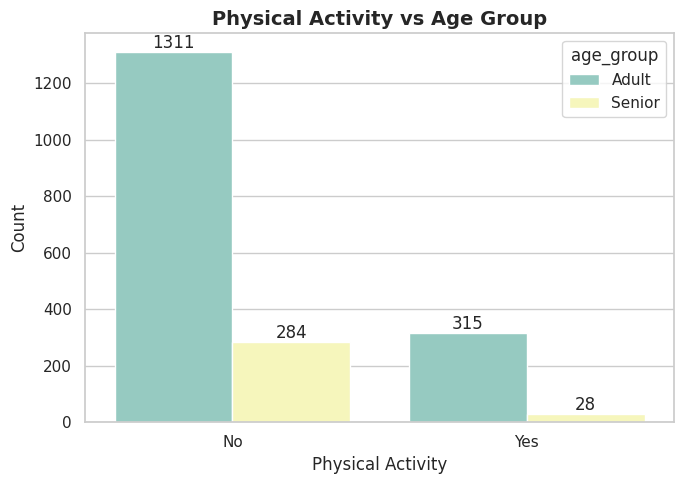

In [209]:
plt.figure(figsize=(7,5))

activity = eda_train.copy()

activity["PAQ605"] = activity["PAQ605"].map({
    1: "Yes",
    2: "No"
})

ax = sns.countplot(
    data=activity,
    x="PAQ605",
    hue="age_group",
    palette="Set3"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Physical Activity vs Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Physical Activity")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### Observation

- Both age groups, Adult and Senior, predominantly report 'No' to physical activity, which is consistent with trends in many populations.
- Seniors appear to have a slightly higher proportion of 'No' responses compared to 'Yes', suggesting a potential decrease in physical activity with age.
- While both groups have a majority reporting 'No' activity, this feature may still hold some predictive power, especially if combined with other health indicators.

## BMI vs Age Group (BMXBMI)

These plots compare the distribution of Body Mass Index (BMI) across different age groups.

### Observation

- Both age groups, Adult and Senior, predominantly report 'No' to physical activity, which is consistent with trends in many populations.
- Seniors appear to have a slightly higher proportion of 'No' responses compared to 'Yes', suggesting a potential decrease in physical activity with age.
- While both groups have a majority reporting 'No' activity, this feature may still hold some predictive power, especially if combined with other health indicators.

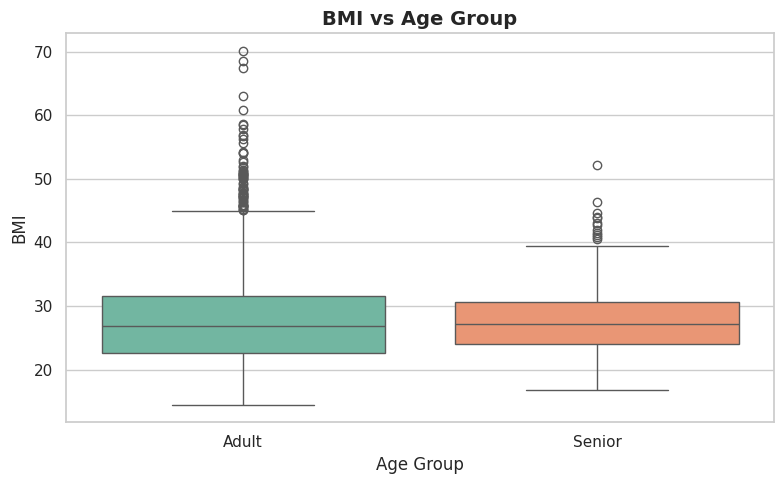

In [210]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_train,
    x="age_group",
    y="BMXBMI",
    palette="Set2"
)

plt.title("BMI vs Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group")
plt.ylabel("BMI")

plt.tight_layout()
plt.show()

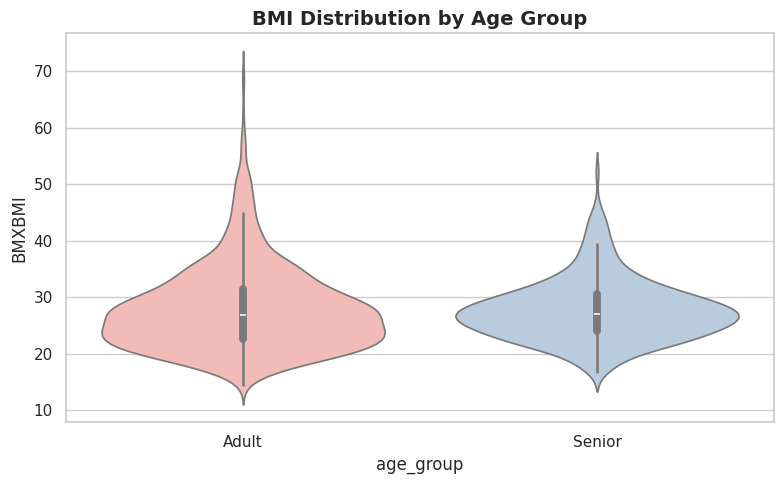

In [211]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=eda_train,
    x="age_group",
    y="BMXBMI",
    palette="Pastel1"
)

plt.title("BMI Distribution by Age Group", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Both the boxplot and violin plot show that BMI distributions for Adults and Seniors largely overlap.
- Seniors tend to have a slightly higher median BMI compared to Adults, indicating a potential increase in BMI with age.
- The spread of BMI values is similar in both groups, though Seniors might exhibit a slightly wider range at the upper end, suggesting more variability in higher BMI categories.
- The presence of outliers in both groups, particularly at higher BMI values, indicates individuals with obesity across all age categories.

## Blood Glucose vs Age Group (LBXGLU)

This plot illustrates how blood glucose levels vary between age groups.

### Observation

- Both the boxplot and violin plot show that BMI distributions for Adults and Seniors largely overlap.
- Seniors tend to have a slightly higher median BMI compared to Adults, indicating a potential increase in BMI with age.
- The spread of BMI values is similar in both groups, though Seniors might exhibit a slightly wider range at the upper end, suggesting more variability in higher BMI categories.
- The presence of outliers in both groups, particularly at higher BMI values, indicates individuals with obesity across all age categories.

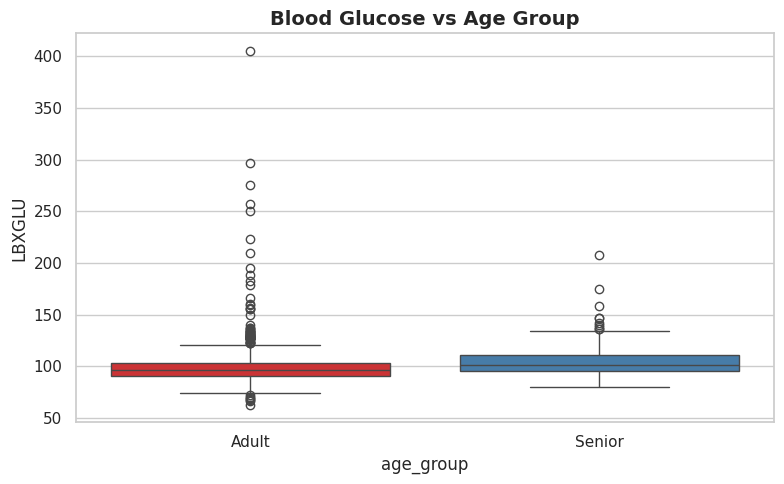

In [212]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_train,
    x="age_group",
    y="LBXGLU",
    palette="Set1"
)

plt.title("Blood Glucose vs Age Group", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Seniors generally exhibit higher median blood glucose levels compared to Adults.
- The spread of blood glucose values in Seniors also appears to be wider, with more pronounced outliers at the higher end, suggesting a greater prevalence of elevated glucose levels in older individuals.
- This observation is consistent with the general understanding that glucose regulation can change with age, making blood glucose a potentially important predictor for age group classification.

## Diabetes Response vs Age Group (DIQ010)

This plot examines the self-reported diabetes status across age groups.

### Observation

- Seniors generally exhibit higher median blood glucose levels compared to Adults.
- The spread of blood glucose values in Seniors also appears to be wider, with more pronounced outliers at the higher end, suggesting a greater prevalence of elevated glucose levels in older individuals.
- This observation is consistent with the general understanding that glucose regulation can change with age, making blood glucose a potentially important predictor for age group classification.

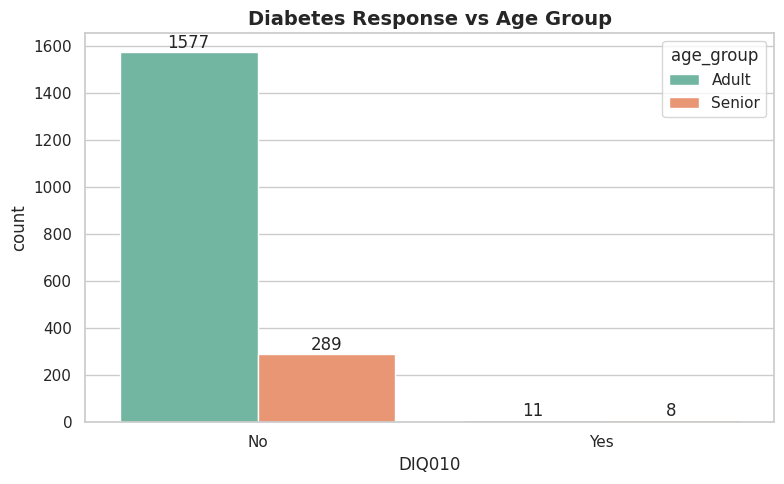

In [213]:
diabetes = eda_train.copy()

diabetes["DIQ010"] = diabetes["DIQ010"].map({
    1: "Yes",
    2: "No"
})

plt.figure(figsize=(8,5))

ax = sns.countplot(
    data=diabetes,
    x="DIQ010",
    hue="age_group",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Diabetes Response vs Age Group", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- While the majority in both age groups report 'No' to diabetes, a visibly higher proportion of Seniors report 'Yes' to diabetes compared to Adults.
- This indicates that diabetes is more prevalent in the Senior age group, aligning with expected demographic health trends.
- The imbalance suggests that this feature will be highly informative in distinguishing between Adults and Seniors.

## Oral Glucose Tolerance vs Age Group (LBXGLT)

This plot shows the distribution of oral glucose tolerance by age group.

### Observation

- While the majority in both age groups report 'No' to diabetes, a visibly higher proportion of Seniors report 'Yes' to diabetes compared to Adults.
- This indicates that diabetes is more prevalent in the Senior age group, aligning with expected demographic health trends.
- The imbalance suggests that this feature will be highly informative in distinguishing between Adults and Seniors.

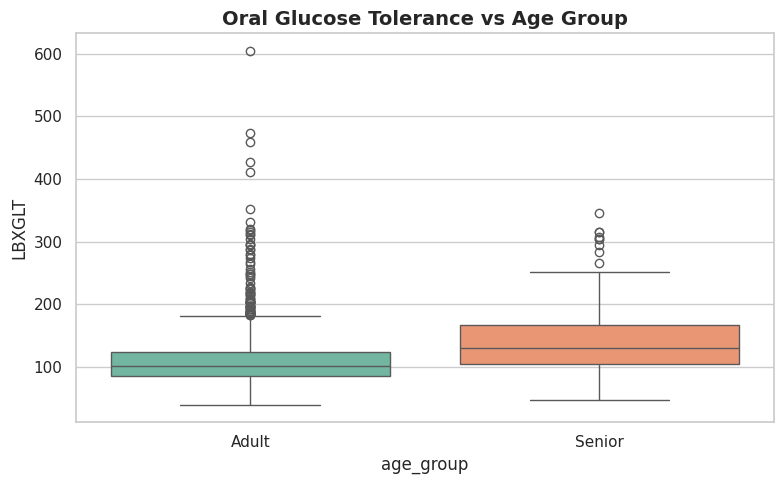

In [214]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_train,
    x="age_group",
    y="LBXGLT",
    palette="Set2"
)

plt.title("Oral Glucose Tolerance vs Age Group", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- Similar to blood glucose, oral glucose tolerance levels (LBXGLT) appear to be higher in Seniors than in Adults.
- The boxplot suggests that the median LBXGLT is elevated in the Senior group, and there are more high-value outliers among Seniors.
- This reinforces the pattern of age-related changes in glucose metabolism and highlights LBXGLT as a significant differentiator between age groups.

## Insulin Level vs Age Group (LBXIN)

This plot illustrates the distribution of insulin levels across age groups.

### Observation

- Similar to blood glucose, oral glucose tolerance levels (LBXGLT) appear to be higher in Seniors than in Adults.
- The boxplot suggests that the median LBXGLT is elevated in the Senior group, and there are more high-value outliers among Seniors.
- This reinforces the pattern of age-related changes in glucose metabolism and highlights LBXGLT as a significant differentiator between age groups.

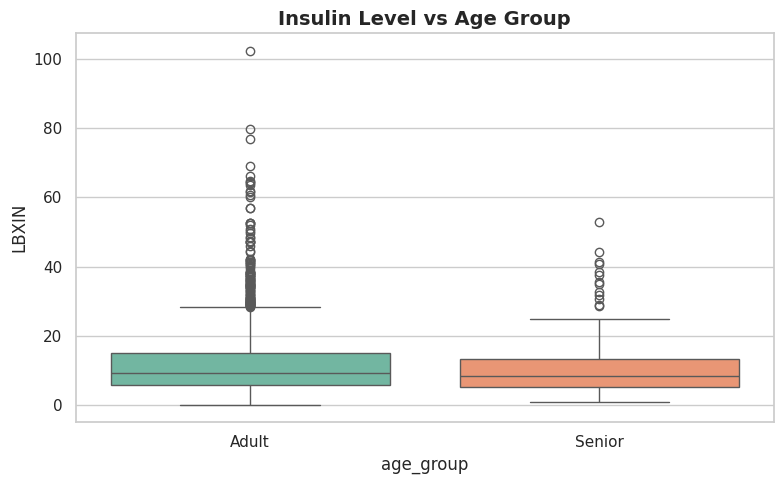

In [215]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=eda_train,
    x="age_group",
    y="LBXIN",
    palette="Set2"
)

plt.title("Insulin Level vs Age Group", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

### Observation

- The boxplot for insulin levels (LBXIN) shows that both age groups have a wide range of values, with a substantial number of extreme outliers.
- While the median insulin level might be slightly higher in Seniors, the most striking feature is the high variability and the presence of very large outliers in both groups, suggesting complex individual differences in insulin regulation.
- The extreme outliers indicate individuals with significantly elevated insulin, which could be a marker for insulin resistance or other conditions present in both Adults and Seniors, but potentially more pronounced or frequent in Seniors.

### Bivariate Analysis Summary

- Seniors appear to have higher median glucose levels than Adults.
- BMI distributions overlap, but Seniors may have a slightly higher median BMI.
- Diabetes is more common among Seniors.
- Physical activity appears lower among Seniors.
- Insulin levels contain large variability and several extreme outliers.
- Gender distribution is relatively balanced across both age groups.

## Correlation Analysis

This section explores the relationships between numerical features using a correlation matrix and pair plots.

In [216]:
# Select only numerical columns
numerical_features = [
    "BMXBMI",
    "LBXGLU",
    "LBXGLT",
    "LBXIN"
]

correlation = eda_train[numerical_features].corr()

correlation

,BMXBMI,LBXGLU,LBXGLT,LBXIN
BMXBMI,1.00,0.21,0.18,0.55
LBXGLU,0.21,1.00,0.67,0.23
LBXGLT,0.18,0.67,1.00,0.22
LBXIN,0.55,0.23,0.22,1.00


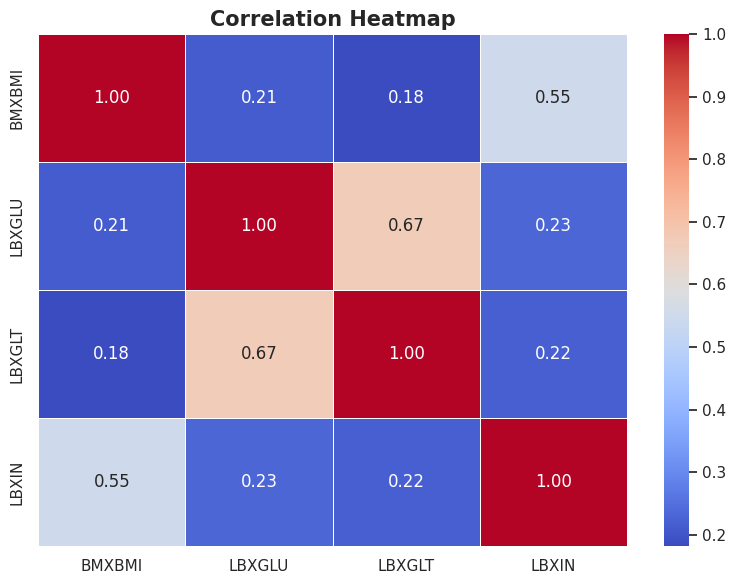

In [217]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()

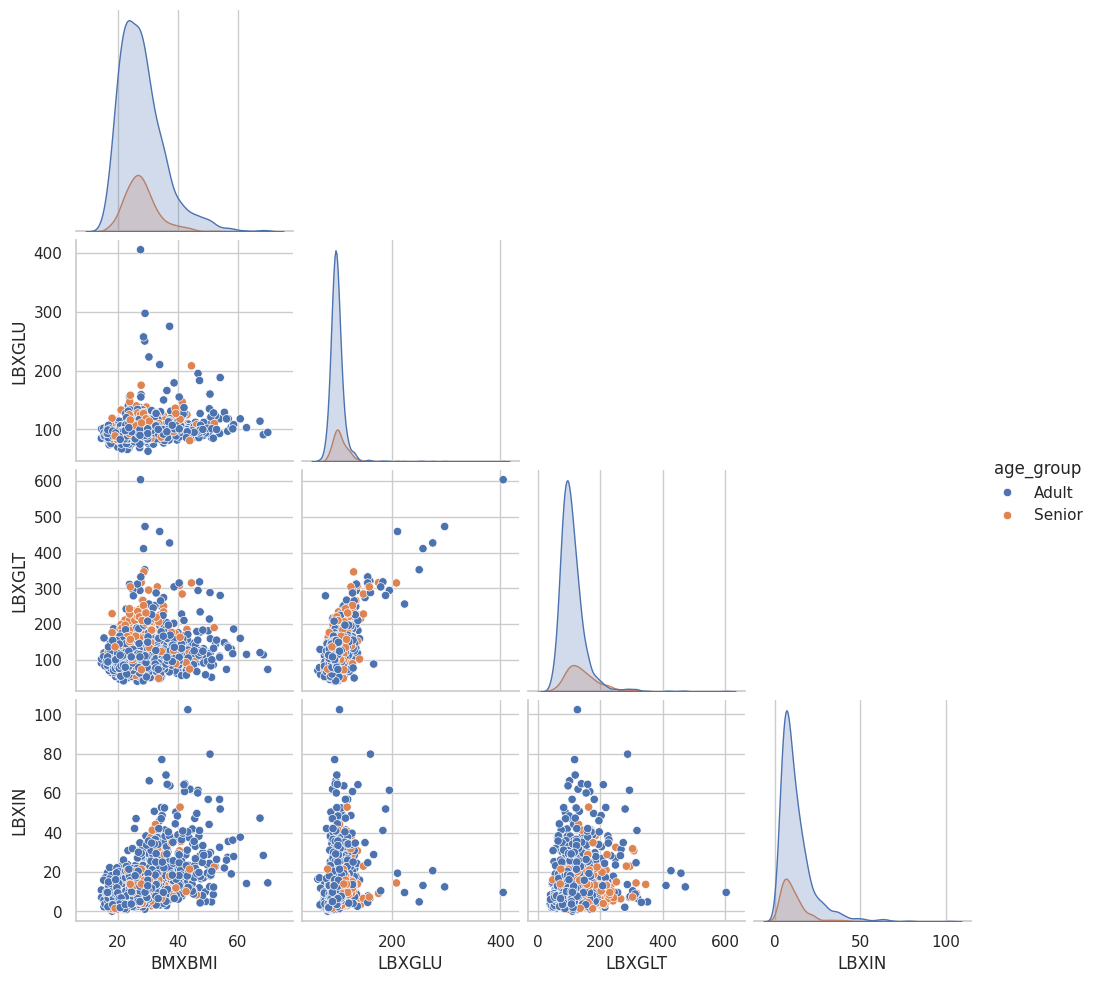

In [218]:
sns.pairplot(
    eda_train,
    vars=numerical_features,
    hue="age_group",
    corner=True
)

plt.show()

### Correlation Analysis Summary

- The pairplot visually confirms the correlations seen in the heatmap and reveals the univariate distributions of each numerical feature, separated by age group.
- It highlights the overlap in distributions but also the subtle shifts in central tendency for features like BMI, Blood Glucose, and Insulin when comparing Adults and Seniors.
- The scatter plots show the relationships between pairs of features, indicating where linear relationships exist and where the data might be more scattered, suggesting weaker correlations or more complex interactions.
- The diagonal histograms/KDEs provide a clearer picture of individual feature distributions for each age group, reinforcing observations from univariate analysis.
- BMI, Blood Glucose, Oral Glucose Tolerance, and Insulin show varying degrees of correlation.
- No pair of features exhibits extremely high correlation (greater than 0.90), indicating that all numerical features may contribute useful information.
- Correlation analysis suggests that interaction features may improve model performance.

## Outlier Analysis

This section focuses on identifying and quantifying outliers within the numerical features.

### Observation

- The pairplot visually confirms the correlations seen in the heatmap and reveals the univariate distributions of each numerical feature, separated by age group.
- It highlights the overlap in distributions but also the subtle shifts in central tendency for features like BMI, Blood Glucose, and Insulin when comparing Adults and Seniors.
- The scatter plots show the relationships between pairs of features, indicating where linear relationships exist and where the data might be more scattered, suggesting weaker correlations or more complex interactions.
- The diagonal histograms/KDEs provide a clearer picture of individual feature distributions for each age group, reinforcing observations from univariate analysis.

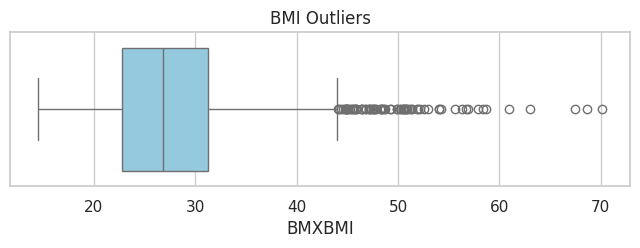

In [219]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=eda_train["BMXBMI"],
    color="skyblue"
)

plt.title("BMI Outliers")

plt.show()

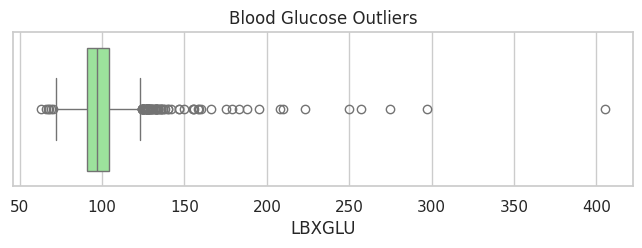

In [220]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=eda_train["LBXGLU"],
    color="lightgreen"
)

plt.title("Blood Glucose Outliers")

plt.show()

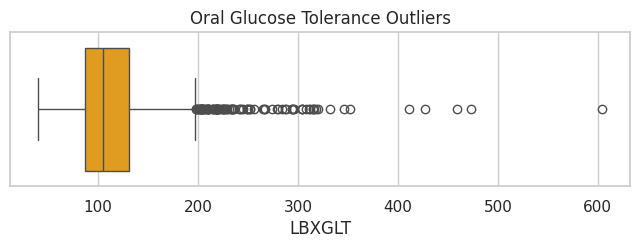

In [221]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=eda_train["LBXGLT"],
    color="orange"
)

plt.title("Oral Glucose Tolerance Outliers")

plt.show()

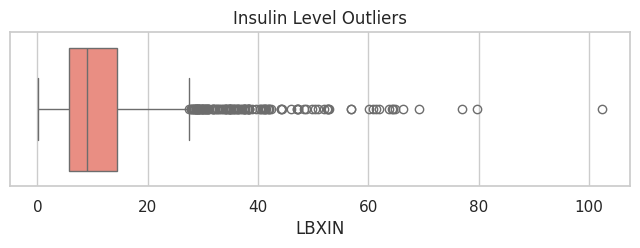

In [222]:
plt.figure(figsize=(8,2))

sns.boxplot(
    x=eda_train["LBXIN"],
    color="salmon"
)

plt.title("Insulin Level Outliers")

plt.show()

In [223]:
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

for column in numerical_features:
    detect_outliers(eda_train, column)

BMXBMI
Number of Outliers: 75
----------------------------------------
LBXGLU
Number of Outliers: 89
----------------------------------------
LBXGLT
Number of Outliers: 96
----------------------------------------
LBXIN
Number of Outliers: 129
----------------------------------------


# Exploratory Data Analysis Summary

## Dataset Overview

- The training dataset contains 1,966 observations.
- Eight predictor variables are available.
- The target variable is **age_group**.

---

## Missing Values

- Missing values are present in all variables.
- The percentage of missing values is below 1%.
- Numerical variables can be imputed using the median.
- Categorical variables can be imputed using the mode.

---

## Class Distribution

- The dataset is imbalanced.
- Adults constitute approximately 84% of the observations.
- Seniors constitute approximately 16%.
- The F1 Score is the appropriate evaluation metric.

---

## Feature Insights

- BMI is positively skewed.
- Blood glucose and insulin distributions contain extreme values.
- Diabetes appears more common among Seniors.
- Physical activity tends to be lower among Seniors.

---

## Correlation

- Moderate correlations exist among metabolic health indicators.
- Interaction features may improve predictive performance.

---

## Outliers

- Several numerical variables contain extreme values.
- These observations are likely medically meaningful and should not be removed without justification.

---

## Planned Feature Engineering

The following features will be created in the next notebook:

- BMI Category
- Obesity Flag
- High Glucose Indicator
- Diabetes Flag
- BMI × Glucose Interaction
- Glucose × Insulin Interaction
- Health Risk Score
- Physical Activity Score